In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import glob
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')
# sns.set_theme(style='white')

In [ ]:
class KuramotoModel(Dataset):
    def __init__(self, sz, groups, batch_size, time_steps, dt, sample_interval, 
                 intra_coupling_strength, inter_coupling_strength, noise_level, use_cache=True):
        """
        Initialize the Kuramoto model dataset.
        
        :param sz: Total number of oscillators
        :param groups: Number of groups/clusters
        :param batch_size: Number of trajectories to generate
        :param time_steps: Total simulation steps
        :param dt: Integration time step
        :param sample_interval: Sampling interval for storing data
        :param intra_coupling_strength: Coupling strength within the same group
        :param inter_coupling_strength: Coupling strength between different groups
        :param noise_level: Noise intensity
        :param flag: "train", "val", or "test" flag
        """
        self.sz = sz
        self.groups = groups
        self.batch_size = batch_size
        self.time_steps = time_steps
        self.dt = dt
        self.sample_interval = sample_interval
        self.intra_coupling_strength = intra_coupling_strength
        self.inter_coupling_strength = inter_coupling_strength
        self.noise_level = noise_level
        
        # Initialize Kuramoto model parameters
        self.obj_matrix, self.group_matrix, self.omegas = self.initialize_kuramoto(sz, groups)
        
  
        self.output_data = self._simulate_multiseries()
        self.time_axis = np.arange(self.output_data.shape[1]) * self.sample_interval * self.dt
            # data_dict = {
            #     'input': self.input,
            #     'output': self.output,
            # }
            # np.save(self.path, data_dict)
    
    def initialize_kuramoto(self, sz, groups):
        """Initialize Kuramoto model connectivity matrices."""
        obj_matrix = torch.full([sz, sz], self.inter_coupling_strength)
        group_matrix = torch.zeros([sz, groups])
        
        # Build a weighted coupling matrix with separate intra-group and inter-group strengths.
        group_size = sz // groups
        for k in range(groups):
            start = k * group_size
            end = (k + 1) * group_size
            obj_matrix[start:end, start:end] = self.intra_coupling_strength
        obj_matrix.fill_diagonal_(0)
        
        # Group membership matrix
        for k in range(groups):
            group_matrix[k * group_size:(k + 1) * group_size, k] = 1
        
        # Natural frequencies
        omegas = torch.randn(sz)
        
        return obj_matrix, group_matrix, omegas
    
    def one_step(self, thetas):
        """Perform one integration step of Kuramoto model."""
        ii = thetas.unsqueeze(0).repeat(thetas.size(0), 1)
        jj = ii.transpose(0, 1)
        dff = jj - ii
        sindiff = torch.sin(dff)
        mult = self.obj_matrix @ sindiff
        dia = torch.diagonal(mult, 0) / self.sz
        noise = torch.randn(self.sz) * self.noise_level
        thetas = self.dt * (self.omegas + dia + noise) + thetas
        return thetas

    def compute_order_parameters(self, thetas):
        """Compute order parameters (group-level observables)."""
        cos_ccs = (torch.cos(thetas) @ self.group_matrix) * self.groups / self.sz
        sin_ccs = (torch.sin(thetas) @ self.group_matrix) * self.groups / self.sz
        return torch.cat([cos_ccs, sin_ccs], dim=0)

    def simulate_oneserie(self):
        """Simulate one trajectory of the Kuramoto model."""
        thetas = torch.rand(self.sz) * 2 * np.pi
        kuramoto_data = []
        
        for t in range(self.time_steps):
            thetas = self.one_step(thetas)
            
            if t % self.sample_interval == 0:
                # Compute observables: sine of phases and order parameters
                phase_obs = torch.sin(thetas)
                # order_params = self.compute_order_parameters(thetas)
                
                # Combine into observation vector (individual phases + group order parameters)
                # obs = torch.cat([phase_obs, order_params])
                kuramoto_data.append(phase_obs.numpy())
        
        return np.array(kuramoto_data)

    def _simulate_multiseries(self):
        """Simulate multiple trajectories."""
        num_obs = int(self.time_steps / self.sample_interval)
        # Output dimension: individual phases (sz) + order parameters (2*groups)
        # output_dim = self.sz + 2 * self.groups
        output_dim = self.sz
        
        kuramoto_data_all = np.zeros([self.batch_size, num_obs, output_dim])
         
        for i in range(self.batch_size):
            kuramoto_data_all[i, :, :] = self.simulate_oneserie()
        
        # Reshape into input-output pairs
        # kuramoto_input = kuramoto_data_all[:, :-1, :].reshape(-1, 1, output_dim)
        # kuramoto_output = kuramoto_data_all[:, 1:, :].reshape(-1, 1, output_dim)

        return kuramoto_data_all

    def get_output_labels(self):
        """Return labels for each observed variable in output_data."""
        labels = [f'phase_obs_{i}' for i in range(self.sz)]
        if self.output_data.shape[-1] == self.sz + 2 * self.groups:
            labels += [f'cos_group_{i}' for i in range(self.groups)]
            labels += [f'sin_group_{i}' for i in range(self.groups)]
        return labels[:self.output_data.shape[-1]]

    def plot_output_data(self, sample_idx=0):
        """Plot each group's observed variables in a separate subplot."""
        series = self.output_data[sample_idx]
        labels = self.get_output_labels()

        base_group_size = self.sz // self.groups
        remainder = self.sz % self.groups
        group_slices = []
        start = 0
        for group_idx in range(self.groups):
            group_size = base_group_size + (1 if group_idx < remainder else 0)
            end = start + group_size
            group_slices.append((start, end))
            start = end

        fig, axes = plt.subplots(self.groups, 1, figsize=(14, 4 * self.groups), sharex=True)
        if self.groups == 1:
            axes = [axes]

        for group_idx, (ax, (start, end)) in enumerate(zip(axes, group_slices)):
            for idx in range(start, end):
                ax.plot(self.time_axis, series[:, idx], linewidth=1.1, alpha=0.85, label=labels[idx])
            ax.set_title(f'Group {group_idx} Output Data Time Series (sample {sample_idx})')
            ax.set_ylabel('Value')
            ax.grid(alpha=0.25)
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)

        axes[-1].set_xlabel('Time')
        plt.tight_layout()
        plt.show()
    
        

    def __len__(self):
        return len(self.input)

    def __getitem__(self, idx):
        return idx, torch.tensor(self.input[idx], dtype=torch.float), torch.tensor(self.output[idx], dtype=torch.float)



In [7]:
model = KuramotoModel(sz=32, groups=2, batch_size=2, time_steps=1000, dt=0.01, sample_interval=1, 
                 intra_coupling_strength=2.0, inter_coupling_strength=0.3, noise_level=0.2)

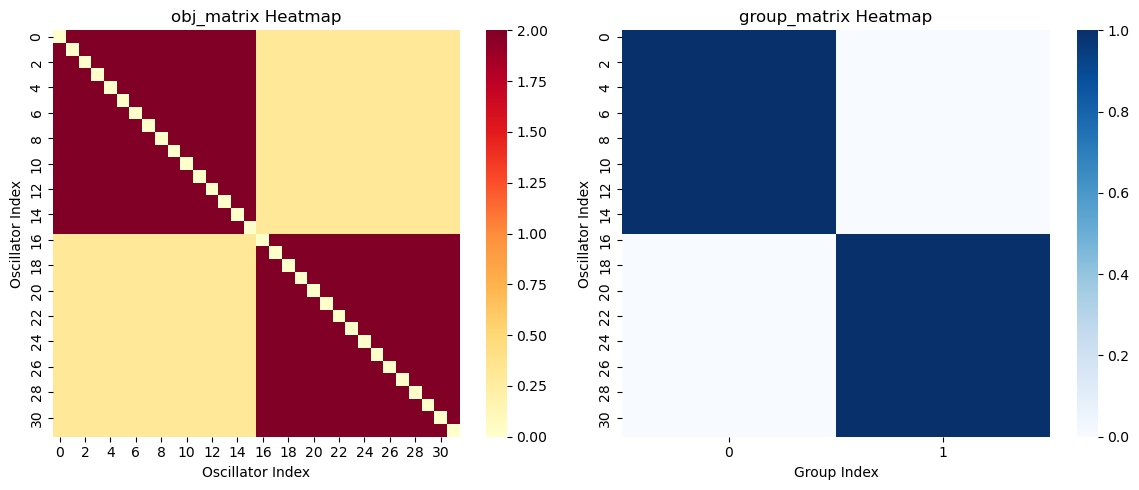

In [8]:
obj_matrix = model.obj_matrix.numpy()
group_matrix = model.group_matrix.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(obj_matrix, ax=axes[0], cmap='YlOrRd', square=True, cbar=True)
axes[0].set_title('obj_matrix Heatmap')
axes[0].set_xlabel('Oscillator Index')
axes[0].set_ylabel('Oscillator Index')

sns.heatmap(group_matrix, ax=axes[1], cmap='Blues', cbar=True)
axes[1].set_title('group_matrix Heatmap')
axes[1].set_xlabel('Group Index')
axes[1].set_ylabel('Oscillator Index')

plt.tight_layout()
plt.show()

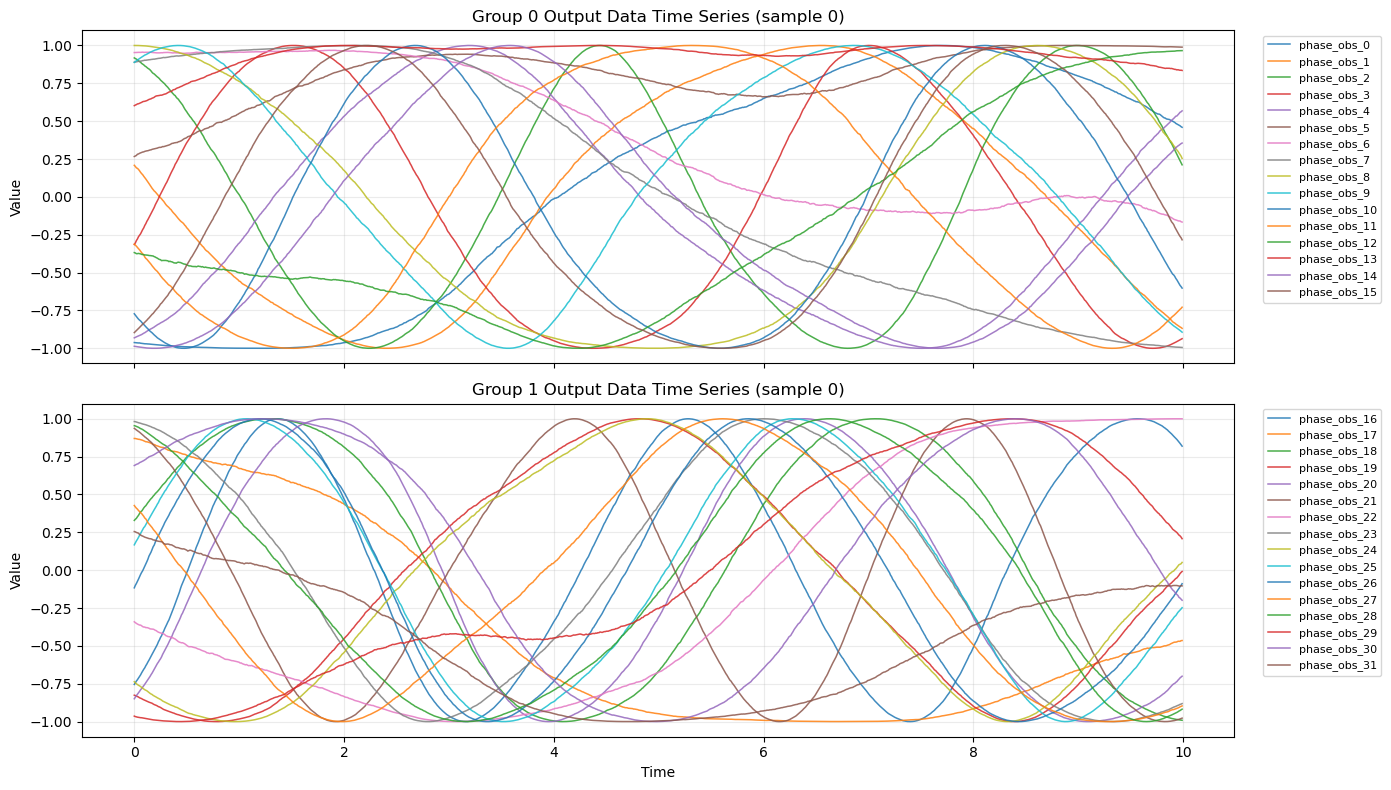

In [9]:
model.plot_output_data(sample_idx=0)

In [10]:
model.plot_order_parameters(sample_idx=0)

AttributeError: 'KuramotoModel' object has no attribute 'theta_data'